# Part 02 — Capacity and C-rate

Nominal capacity tells us how much electric charge a cell is rated to deliver **under specified test conditions**. C-rate tells us how large the applied current is relative to that nominal capacity.

By the end of this notebook, you should be able to:

- calculate current from nominal capacity and C-rate;
- calculate the ideal duration associated with a C-rate;
- explain why current–time rectangles have equal area for equal transferred charge; and
- separate exact C-rate arithmetic from real-cell voltage-cutoff behavior.

The example cell used throughout the lesson has a nominal capacity of **20 Ah**. All calculations use the tested `battery_core` package functions.

## 1. C-rate is a normalized current and a reciprocal-time quantity

For current magnitude $I$ in amperes and nominal capacity $Q_\mathrm{nominal}$ in ampere-hours,

$$
C_\mathrm{rate}=\frac{I}{Q_\mathrm{nominal}}.
$$

The units show why C-rate is connected to time:

$$
\frac{[\mathrm{A}]}{[\mathrm{A}\cdot\mathrm{h}]}=\mathrm{h}^{-1}.
$$

Battery engineers commonly write labels such as **C/10**, **1C**, **2C**, and **10C**. For example, 2C means that the current in amperes is twice the numerical nominal-capacity value in ampere-hours. For a 20 Ah cell, 2C is therefore 40 A.

The two ideal relationships are

$$
I=C_\mathrm{rate}Q_\mathrm{nominal},
\qquad
t_\mathrm{ideal}=\frac{1}{C_\mathrm{rate}}.
$$

The second expression does not contain capacity because the current has already been normalized by capacity. It is an **ideal charge-transfer duration**, not a prediction of real terminal-voltage cutoff time.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

from battery_core import (
    c_rate_from_current,
    current_from_c_rate,
    ideal_duration_hours,
)

NOMINAL_CAPACITY_AH = 20.0
C_RATES = np.array([0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0])
RATE_LABELS = ["C/10", "C/5", "C/2", "1C", "2C", "5C", "10C"]


def pretty_time(hours: float) -> str:
    # Format a duration in hours or minutes for display.
    return f"{hours:.2f} h" if hours >= 1.0 else f"{hours * 60.0:.0f} min"


currents_a = current_from_c_rate(
    nominal_capacity_ah=NOMINAL_CAPACITY_AH, c_rate=C_RATES
)
durations_h = ideal_duration_hours(C_RATES)

print(f"Nominal capacity: {NOMINAL_CAPACITY_AH:.0f} Ah\n")
print(f"{'Rate':>7}  {'Current [A]':>11}  {'Ideal duration':>14}")
print("-" * 38)
for label, current, duration in zip(RATE_LABELS, currents_a, durations_h, strict=True):
    print(f"{label:>7}  {current:11.1f}  {pretty_time(float(duration)):>14}")

Nominal capacity: 20 Ah

   Rate  Current [A]  Ideal duration
--------------------------------------
   C/10          2.0         10.00 h
    C/5          4.0          5.00 h
    C/2         10.0          2.00 h
     1C         20.0          1.00 h
     2C         40.0          30 min
     5C        100.0          12 min
    10C        200.0           6 min


## 2. Reading the table

Three patterns are worth pausing on.

**1C is the reference point.** For the 20 Ah example, 1C corresponds to 20 A and an ideal duration of 1 hour.

**Doubling C-rate doubles current and halves ideal duration.** Moving from 1C to 2C changes 20 A to 40 A and 1 hour to 30 minutes.

**At the same C-rate, ideal duration is the same for different capacities.** A 3 Ah cell and a 300 Ah cell both have an ideal duration of 30 minutes at 2C, but the required currents are 6 A and 600 A.

This normalization makes C-rate useful for comparison. A current value by itself does not tell us how demanding the load is until we know the cell capacity.

## 3. Why duration is reciprocal: capacity is area under current versus time

Electric charge is the time integral of current:

$$
Q=\int I(t)\,dt.
$$

For constant current, this reduces to

$$
Q=It.
$$

On a current-versus-time graph, transferred charge is therefore the **area under the curve**. In the ideal arithmetic below, every rectangle has an area of 20 Ah:

- C/2: $10\ \mathrm{A}\times2\ \mathrm{h}=20\ \mathrm{Ah}$;
- 1C: $20\ \mathrm{A}\times1\ \mathrm{h}=20\ \mathrm{Ah}$;
- 2C: $40\ \mathrm{A}\times0.5\ \mathrm{h}=20\ \mathrm{Ah}$.

A taller rectangle must be narrower when the area is fixed. That geometric picture is the reciprocal relationship $t_\mathrm{ideal}=1/C_\mathrm{rate}$.

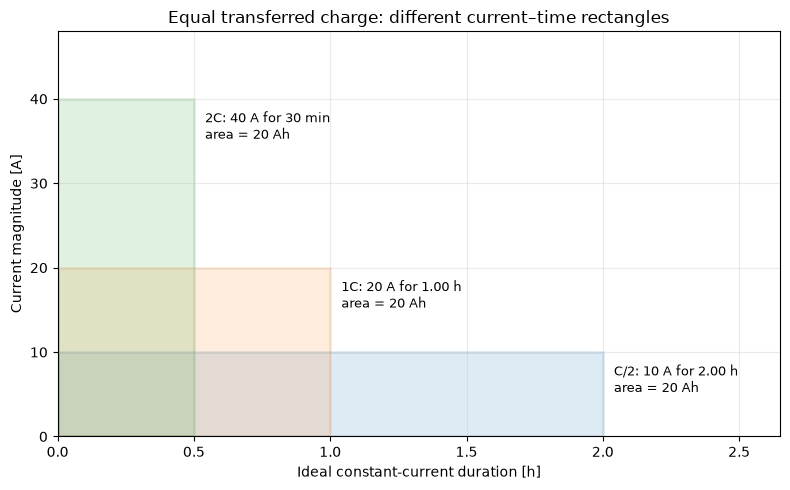

In [2]:
area_rates = np.array([0.5, 1.0, 2.0])
area_labels = ["C/2", "1C", "2C"]
area_currents = current_from_c_rate(
    nominal_capacity_ah=NOMINAL_CAPACITY_AH, c_rate=area_rates
)
area_durations = ideal_duration_hours(area_rates)
plot_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = plt.subplots(figsize=(8, 5))

for index, (label, current, duration) in enumerate(
    zip(area_labels, area_currents, area_durations, strict=True)
):
    color = plot_colors[index]
    rectangle = Rectangle(
        (0.0, 0.0),
        float(duration),
        float(current),
        facecolor=color,
        edgecolor=color,
        alpha=0.14,
        linewidth=2,
    )
    ax.add_patch(rectangle)
    ax.annotate(
        f"{label}: {current:.0f} A for {pretty_time(float(duration))}\n"
        f"area = {current * duration:.0f} Ah",
        xy=(float(duration), float(current)),
        xytext=(8, -8),
        textcoords="offset points",
        fontsize=9,
        va="top",
    )

ax.set(
    xlim=(0.0, 2.65),
    ylim=(0.0, 48.0),
    xlabel="Ideal constant-current duration [h]",
    ylabel="Current magnitude [A]",
    title="Equal transferred charge: different current–time rectangles",
)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

## 4. Ideal duration is not a real-cell runtime prediction

The equal-area picture assumes that the full nominal capacity is available at the selected current. A real cell is normally stopped when terminal voltage reaches a specified limit, and the usable charge before that limit depends on the cell and test conditions.

| Effect | Why measured duration can change |
|---|---|
| **Ohmic voltage drop** | A larger current produces a larger instantaneous terminal-voltage drop and can cause the lower cutoff voltage to be reached sooner. |
| **Polarization and transport limitations** | Concentration gradients and reaction overpotentials generally increase with current, changing the charge accessible before cutoff. |
| **Temperature** | Temperature changes resistance, kinetics, transport, and usable capacity. |
| **Chemistry and design** | Electrode thickness, particle size, electrolyte, and other design choices affect rate capability. |
| **State of health** | Aging changes both capacity and resistance. |
| **Rating and test definition** | Nominal capacity is tied to specified current, temperature, rest conditions, and voltage limits. |

At high current, a cell often reaches its lower voltage limit before delivering its nominal charge. However, the ideal duration should not be treated as a universal upper or lower bound: actual usable capacity can be below, near, or sometimes above the nameplate value depending on the rating procedure and conditions.

This notebook intentionally does **not** draw a synthetic rate-capacity curve. Predicting cutoff time requires measured discharge data or a validated voltage model with cell-specific parameters.

## 5. Worked example

A datasheet lists a **3.2 Ah** cell with a maximum continuous discharge current of **15 A**. Calculate the corresponding C-rate and ideal duration.

In [3]:
example_capacity_ah = 3.2
example_current_a = 15.0

example_c_rate = c_rate_from_current(
    current_a=example_current_a, nominal_capacity_ah=example_capacity_ah
)
example_duration_h = ideal_duration_hours(example_c_rate)

print(f"C-rate: {example_c_rate:.2f}C")
print(f"Ideal duration: {example_duration_h:.3f} h")
print(f"Ideal duration: {example_duration_h * 60.0:.1f} min")

C-rate: 4.69C
Ideal duration: 0.213 h
Ideal duration: 12.8 min


The ideal calculation gives approximately **4.69C** and **12.8 minutes**.

That result is a reference calculation, not a guarantee that the cell can remain above its lower voltage limit for 12.8 minutes at 15 A. The actual duration must be obtained from a relevant datasheet discharge curve, measured data, or a validated model at the specified temperature, voltage limits, and cell condition.

## 6. Check yourself

1. A 50 Ah cell is discharged at 25 A. What is its C-rate and ideal duration?
2. Which has the shorter ideal duration at 2C: a 5 Ah cell or a 100 Ah cell?
3. A 20 Ah cell is discharged at 40 A for 25 minutes before reaching its cutoff voltage. How much charge was delivered, and how does that compare with the nominal capacity?
4. Explain why “10C always lasts exactly 6 minutes” is not a valid real-cell prediction.

<details>
<summary><b>Answers</b></summary>

1. $25/50=0.5\mathrm{C}$, so the ideal duration is $1/0.5=2$ hours.
2. Neither. Both have an ideal duration of 30 minutes. Their currents differ: 10 A for the 5 Ah cell and 200 A for the 100 Ah cell.
3. The delivered charge is $40\times(25/60)=16.7$ Ah, about 3.3 Ah below the nominal rating under those test conditions. This observation alone does not determine how much charge would be usable at a different current, temperature, or cutoff voltage.
4. Six minutes follows from the ideal reciprocal relationship. Real cutoff time also depends on voltage limits, resistance, polarization, temperature, chemistry, design, state of health, and the capacity-rating procedure.

</details>